# HW3 Report

Name: Tianna Calderon

Collaborators:


<br>Wikipedia Page: https://en.wikipedia.org/wiki/Loop_unrolling
<br>Stack Overflow: https://stackoverflow.com/questions/7395556/why-does-the-order-of-loops-in-a-matrix-multiply-algorithm-affect-performance
<br>Redhat: https://developers.redhat.com/blog/2019/04/02/how-data-layout-affects-memory-performance
<br> Lectures

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

## Part 1: Optimizing dot product (30%)

Write your analysis/commentary here for Part 1. You can use LaTeX-style math, e.g., $n^2$ and
$$ \sum_{i=0}^{n-1} a_i b_i .$$



Answering the questions:
1) Is this code correct for all values of n?
   Yes, in the code we can validate that the code has correct values of n based on the fact that the code checks for tolerances and if the result is within that range.

   i.e.

    ```
    if (fabs(result - flops) > 1e-10)
      printf("Result %f failed to validate with expected value %ld\n", result, flops);
    ```
    
    if the values value to be in between the parameter then the value of n is incorrect.

2) Can this code change the numerically computed result?

    No, it only calculates the dot product and the time it takes to calculate the said solution. We can see this with the output of the ticks and the flops.

   
    3) Can you extend this technique to increase performance further (longer vector registers and/or more instruction-level parallelism)?

    Yes, by the floating point precision errors. If the computer has a better way to handle it then we can see better output. For example, if we use a double versus a float there may be more precision error with the double based on the fact it has less values than the float.

   You can possibly extend the technique with paralleization as it would remove the non-associativity to the float addition. We spoke about this in class with the algorithmic limitations. Due to the code having to perform in a certain manner currently, this causes the performance to be a little slower. An option to improve the performance is to implement parallelization so that it doesn't follow the algorithm. It uses threads to create their own results and then combine in the end. This split in performance can aid in the actual performance.

4) Can you make the unrolling factor 2 a compile-time constant, perhaps by using an inneloop?5
    
       Yes, below is the current code.

    ```
    
        double dot_opt_even_odd(size_t n, const double *a, const double *b) {
      double sum0 = 0, sum1 = 0;
      for (size_t i=0; i<n; i+=2) {
        sum0 += a[i+0] * b[i+0];
        sum1 += a[i+1] * b[i+1];
      }
      return sum0 + sum1;
    }
    ```

    A way it could be improved is by adding an outside variable for holding the partial sums.

    Then make a second loop to provess the unroll factors
    
    ```
    // define a variable for unrolling we're told at 2

    #define UNROLL_FACTOR 2

    // Optimized dot product with unrolling factor 2
    double dot_opt_even_odd(size_t n, const double *a, const double *b) {
        double sum[UNROLL_FACTOR] = {0}; // Array to hold partial sums

    // Outer loop: take computation in chunks for faster computation
        for (i = 0; i + UNROLL_FACTOR <= n; i += UNROLL_FACTOR) {
            for (size_t j = 0; j < UNROLL_FACTOR; j++) {
                sum[j] += a[i + j] * b[i + j]; //does computation in chunks of 2
            }
        }

        // Handle remaining elements (if n is not a multiple of UNROLL_FACTOR)
        // values that are odd...
        for (; i < n; i++) {
            sum[0] += a[i] * b[i];
        }

        // Combine partial sums
        double total_sum = 0;
        for (size_t j = 0; j < UNROLL_FACTOR; j++) {
            total_sum += sum[j];
        }

        return total_sum;
    }
    ```
    <br>
    There could probably be more improvements made in this code with the odd value loop and the combindation fo the partial sums.. but I ran out of time
    <br>
5) 
Could that unrolling factor be a run-time paramter?t

    Yes, but based on what is going on the code. It being a compile-time unrolling we wouldn't know the compile time at the point at which the function is called. So there would need to be some changes to the overall code. Furthermore, if we are still looking for performance increase, this might take up more binary size.  Reef from lecture and the wikipedia page) which could be counterproductie.?


 ## Performance Impact of even-odd index technique vs dot_ref (vanilla technique)

In [2]:
df = pd.read_csv("results.csv")
p1_even_odd = df.iloc[:,10:15]#stores ref output for n = 10000
p1_dot = df.iloc[:,5:10] #stores even_odd output for n = 10000
p2 = df.iloc[:,:5] #stores b_opt for n = 10000

print(f"Output for dot.c file\n", p1_dot)

Output for dot.c file
    File.1    Name.1  flops.1   ticks.1  flops/tick.1
0     dot   dot_ref  20000.0   25371.0          0.79
1     dot   dot_ref  20000.0   25396.0          0.79
2     dot   dot_ref  20000.0   34235.0          0.58
3     dot   dot_ref  20000.0   26020.0          0.77
4     dot   dot_ref  20000.0   26002.0          0.77
5     dot   dot_ref  20000.0   25999.0          0.77
6     dot   dot_ref  20000.0   26016.0          0.77
7     dot   dot_ref  20000.0   25996.0          0.77
8     dot   dot_ref  20000.0   25999.0          0.77
9     dot   dot_ref  20000.0   25996.0          0.77
10    dot  dot_opt1  20000.0  413763.0          0.05
11    dot  dot_opt1  20000.0   19757.0          1.01
12    dot  dot_opt1  20000.0   16735.0          1.20
13    dot  dot_opt1  20000.0   16699.0          1.20
14    dot  dot_opt1  20000.0   16896.0          1.18
15    dot  dot_opt1  20000.0   16551.0          1.21
16    dot  dot_opt1  20000.0   15976.0          1.25
17    dot  dot_opt1  20

In [4]:
print(f"Output for dot_even_odd.c (pt 1.2)file\n", p1_even_odd)

Output for dot_even_odd.c (pt 1.2)file
           File.2       Name.2  flops.2  ticks.2  flops/tick.2
0   dot_even_odd      dot_ref    20000    25774          0.78
1   dot_even_odd      dot_ref    20000    25360          0.79
2   dot_even_odd      dot_ref    20000    34551          0.58
3   dot_even_odd      dot_ref    20000    26022          0.77
4   dot_even_odd      dot_ref    20000    26020          0.77
5   dot_even_odd      dot_ref    20000    26055          0.77
6   dot_even_odd      dot_ref    20000    26040          0.77
7   dot_even_odd      dot_ref    20000    26017          0.77
8   dot_even_odd      dot_ref    20000    26011          0.77
9   dot_even_odd      dot_ref    20000    26023          0.77
10  dot_even_odd  dot_opt_eve    20000    19480          1.03
11  dot_even_odd  dot_opt_eve    20000    20492          0.98
12  dot_even_odd  dot_opt_eve    20000    20992          0.95
13  dot_even_odd  dot_opt_eve    20000    20694          0.97
14  dot_even_odd  dot_opt_eve 

In [5]:
print(f"Output for dotpt2.c (pt2) file\n", p2)

Output for dotpt2.c (pt2) file
       File      Name    flops     ticks  flops/tick
0   dotpt2   dot_ref  20000.0   25505.0        0.78
1   dotpt2   dot_ref  20000.0   32371.0        0.62
2   dotpt2   dot_ref  20000.0   26026.0        0.77
3   dotpt2   dot_ref  20000.0   26058.0        0.77
4   dotpt2   dot_ref  20000.0   26023.0        0.77
5   dotpt2   dot_ref  20000.0   26026.0        0.77
6   dotpt2   dot_ref  20000.0   26029.0        0.77
7   dotpt2   dot_ref  20000.0   26023.0        0.77
8   dotpt2   dot_ref  20000.0   26043.0        0.77
9   dotpt2   dot_ref  20000.0   26029.0        0.77
10  dotpt2  dot_opt1  20000.0  478625.0        0.04
11  dotpt2  dot_opt1  20000.0   20599.0        0.97
12  dotpt2  dot_opt1  20000.0   16340.0        1.22
13  dotpt2  dot_opt1  20000.0   16185.0        1.24
14  dotpt2  dot_opt1  20000.0   16905.0        1.18
15  dotpt2  dot_opt1  20000.0   16158.0        1.24
16  dotpt2  dot_opt1  20000.0   15926.0        1.26
17  dotpt2  dot_opt1  20000.0   

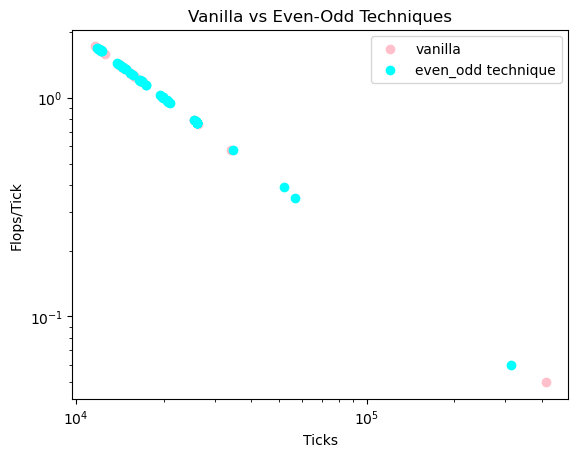

In [15]:
col = mcolors.TABLEAU_COLORS

fig = plt.figure()
ax = fig.gca()
ax.scatter(p1_dot.iloc[:, 3], p1_dot.iloc[:, 4], label = "vanilla", c = "pink")
ax.scatter(p1_even_odd.iloc[:, 3], p1_even_odd.iloc[:, 4], label = "even_odd technique", c = "cyan")
ax.set_xlabel("Ticks")
ax.set_ylabel("Flops/Tick")
ax.loglog()
ax.set_title("Vanilla vs Even-Odd Techniques")
ax.legend()
plt.show()

fig.savefig('Vanilla vs Even-Odd Techniques.png')



It takes less time for the vanilla technique. 
Initially Even-Odd has higher Flops/Tick but as time progresses, even_odd takes longer.

## Part 2: Optimizing block inner product (%70)

Write your analysis/commentary here for Part 1.
Comparison between the optimization (the graph)


1) What does it mean to reorder loops? Will it help or hurt performance?

   Loop re-ordering means changing the way the way we access memory. Depending on the order or index of the loops this can change the cache performance.
    In this case, as we see in class memory is split into a hierarchy with several caches If we can allow for the most important memory to be in 
    cache and the latter down the hierarchy then you are able to improve the memory. What we see with loop unrolling is reducing the amount
    of algorithms or instructions a computer might need to perform certain actions. So, to answer the question depending on how the loop is written, it
   may be able to increase performance or decrease it.
   
2) Does it help to change the layout in memory (see the aistride, ajstride, bistride, and bkstride parameters in the code)?

    
    Yes, if we can remove how much time it takes to access the memory this can improve the performance. Going back to what was discuss earlier, if the the memory object is closer/higher on the hierarchy then the memory might move faster. It depends on how much memory is being used though.
    
3) Try using the #pragma omp simd directive seen in class and the compiler option -fopenmp-simd.

    It doesn't work for how I implemented it, because the loop is too simple for the #pragma omp simd to compile. I believe though that if there is enough memory allocated for the task, and the loop is set to scalar it should be able to work


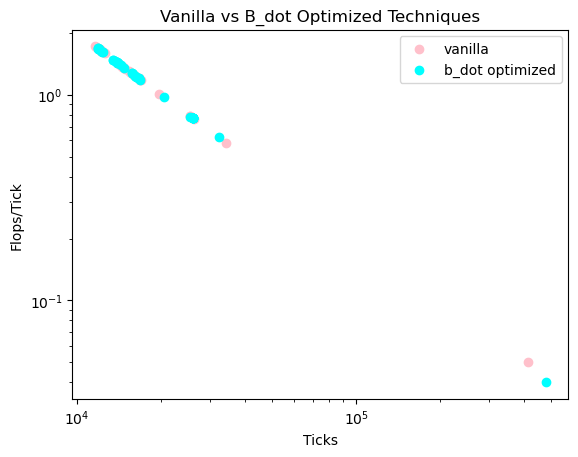

In [16]:
#Problem 2: Output with bdot_opt

fig = plt.figure()
ax = fig.gca()
ax.scatter(p1_dot.iloc[:, 3], p1_dot.iloc[:, 4], label = "vanilla", c = "pink")
ax.scatter(p2.iloc[:, 3], p2.iloc[:, 4], label = "b_dot optimized", c = "cyan")
ax.loglog()
ax.set_xlabel("Ticks")
ax.set_ylabel("Flops/Tick")
ax.set_title("Vanilla vs B_dot Optimized Techniques")
ax.legend()
plt.show()

fig.savefig('Vanilla vs B_dot Optimized Techniques.png')

### Response:
We see that b_dot takes longer to compile, despite being more optimized? This maybe caused by the memory allocation. If the memory for b_opt is stored further down in memory it will take longer to access.. 
I do notice that there is an accumulation of value points for b_dot around 1.25 - 1.5 this could possibly be the peak of optimization for the value. 

I think another thing I would like to try next time if given more time is implementing the omp simd.. I think if I had more time to figure out where the issue was on the memory allocation I would like to see the differences in allocation between the two...